In [1]:
# Imports necessários

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import OneHotEncoder
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

In [3]:
# Coleta de dados

clientes_df = pd.read_csv('adesao_investimentos.csv')
estados_df = pd.read_csv('estado_regiao.csv')

In [4]:
print("Informações Iniciais:")
print(clientes_df.head(5))
print("Informações do dataset:")
print(clientes_df.info())
print("\nEstatísticas descritivas:")
print(clientes_df.describe())

Informações Iniciais:
   idade    estado_civil escolaridade possui_inadimplencia  saldo_carteira  \
0   45.0      casado (a)     superior                  não             242   
1   42.0      casado (a)        medio                  não            1289   
2   23.0    solteiro (a)     superior                  não             363   
3   58.0  divorciado (a)     superior                  não            1382   
4   50.0      casado (a)        medio                  não            3357   

  fez_emprestimo  ultimo_contato_tempo  numero_contatos fez_investimento  \
0            não                   587                1              sim   
1            não                   250                4              sim   
2            não                    16               18              não   
3            não                   700                1              sim   
4            não                   239                4              sim   

   cod_estado  
0          27  
1          11  
2   

In [5]:
print("Informações Iniciais:")
print(estados_df.head(5))
print("Informações do dataset:")
print(estados_df.info())
print("\nEstatísticas descritivas:")
print(estados_df.describe())

Informações Iniciais:
   id_estado sigla    estado    regiao    pais
0          1    AC      Acre     Norte  Brasil
1          2    AL   Alagoas  Nordeste  Brasil
2          3    AP     Amapá     Norte  Brasil
3          4    AM  Amazonas     Norte  Brasil
4          5    BA     Bahia  Nordeste  Brasil
Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_estado  27 non-null     int64 
 1   sigla      27 non-null     object
 2   estado     27 non-null     object
 3   regiao     27 non-null     object
 4   pais       27 non-null     object
dtypes: int64(1), object(4)
memory usage: 1.2+ KB
None

Estatísticas descritivas:
       id_estado
count  27.000000
mean   14.000000
std     7.937254
min     1.000000
25%     7.500000
50%    14.000000
75%    20.500000
max    27.000000


In [6]:
print("\nValores ausentes no Dataset de Clientes:")
print(clientes_df.isnull().sum())

print("\nValores ausentes no Dataset de Estados:")
print(estados_df.isnull().sum())

print(f"Número de duplicatas no Dataset de Clientes: {clientes_df.duplicated().sum()}")
clientes_df.drop_duplicates(inplace=True)

print(f"Número de duplicatas no Dataset de Estados: {estados_df.duplicated().sum()}")
estados_df.drop_duplicates(inplace=True)


Valores ausentes no Dataset de Clientes:
idade                    6
estado_civil             0
escolaridade            11
possui_inadimplencia     0
saldo_carteira           0
fez_emprestimo           0
ultimo_contato_tempo     0
numero_contatos          0
fez_investimento         0
cod_estado               0
dtype: int64

Valores ausentes no Dataset de Estados:
id_estado    0
sigla        0
estado       0
regiao       0
pais         0
dtype: int64
Número de duplicatas no Dataset de Clientes: 277
Número de duplicatas no Dataset de Estados: 0


In [7]:
# Dados Categóricos (moda)
for coluna in clientes_df.select_dtypes(include=['object']).columns:
    moda = clientes_df[coluna].mode()[0]
    clientes_df.loc[clientes_df[coluna].isnull(), coluna] = moda

for coluna in estados_df.select_dtypes(include=['object']).columns:
    moda = estados_df[coluna].mode()[0]
    estados_df.loc[estados_df[coluna].isnull(), coluna] = moda

# Dados Numéricos (média com arredondamento)
for coluna in clientes_df.select_dtypes(include=['int64', 'float64']).columns:
    media = clientes_df[coluna].mean()
    media_arredondada = round(media)  # Arredonda a média
    clientes_df.loc[clientes_df[coluna].isnull(), coluna] = media_arredondada

for coluna in estados_df.select_dtypes(include=['int64', 'float64']).columns:
    media = estados_df[coluna].mean()
    media_arredondada = round(media)  # Arredonda a média
    estados_df.loc[estados_df[coluna].isnull(), coluna] = media_arredondada

In [8]:
# Verificações pós-tratamento

# Verificação de Valores Ausentes
print("\nVerificação pós-tratamento de valores ausentes:")
print("\nValores ausentes no Dataset de Clientes:")
print(clientes_df.isnull().sum())

print("\nValores ausentes no Dataset de Estados:")
print(estados_df.isnull().sum())

# Verificação de Valores Duplicados
print("\nVerificação pós-tratamento de duplicatas:")
print(f"\nNúmero de duplicatas no Dataset de Clientes após: {clientes_df.duplicated().sum()}")
print(f"Número de duplicatas no Dataset de Estados após: {estados_df.duplicated().sum()}")

# Verificação dos Tipos de Dados (Opcional)
print("\nTipos de dados do Dataset de Clientes:")
print(clientes_df.dtypes)

print("\nTipos de dados do Dataset de Estados:")
print(estados_df.dtypes)


Verificação pós-tratamento de valores ausentes:

Valores ausentes no Dataset de Clientes:
idade                   0
estado_civil            0
escolaridade            0
possui_inadimplencia    0
saldo_carteira          0
fez_emprestimo          0
ultimo_contato_tempo    0
numero_contatos         0
fez_investimento        0
cod_estado              0
dtype: int64

Valores ausentes no Dataset de Estados:
id_estado    0
sigla        0
estado       0
regiao       0
pais         0
dtype: int64

Verificação pós-tratamento de duplicatas:

Número de duplicatas no Dataset de Clientes após: 0
Número de duplicatas no Dataset de Estados após: 0

Tipos de dados do Dataset de Clientes:
idade                   float64
estado_civil             object
escolaridade             object
possui_inadimplencia     object
saldo_carteira            int64
fez_emprestimo           object
ultimo_contato_tempo      int64
numero_contatos           int64
fez_investimento         object
cod_estado                int64


In [9]:
# Integrando as tabelas (inner join)
df_completo = pd.merge(clientes_df, estados_df, left_on='cod_estado', right_on='id_estado', how='inner')

# Ordenação baseada no INDEX conforme solicitado
df_completo.sort_index(inplace=True)

# Exibindo as primeiras linhas e informações do DataFrame resultante
print("Primeiras linhas do DataFrame Completo:")
print(df_completo.head())

print("\nInformações do DataFrame Completo:")
print(df_completo.info())

Primeiras linhas do DataFrame Completo:
   idade    estado_civil escolaridade possui_inadimplencia  saldo_carteira  \
0   45.0      casado (a)     superior                  não             242   
1   42.0      casado (a)        medio                  não            1289   
2   23.0    solteiro (a)     superior                  não             363   
3   58.0  divorciado (a)     superior                  não            1382   
4   50.0      casado (a)        medio                  não            3357   

  fez_emprestimo  ultimo_contato_tempo  numero_contatos fez_investimento  \
0            não                   587                1              sim   
1            não                   250                4              sim   
2            não                    16               18              não   
3            não                   700                1              sim   
4            não                   239                4              sim   

   cod_estado  id_estado sigla    

In [10]:
# Supondo que 'df_completo' é o DataFrame resultante da junção

# Filtrar o DataFrame para obter apenas os clientes de São Paulo
clientes_sao_paulo = df_completo[df_completo['estado'] == 'São Paulo']

# Calcular a média das idades dos clientes de São Paulo
media_idades_sao_paulo = clientes_sao_paulo['idade'].mean()

# Imprimir o resultado
print(f"A média das idades dos clientes que residem em São Paulo é: {media_idades_sao_paulo:.2f}")

A média das idades dos clientes que residem em São Paulo é: 41.82


In [11]:
# Supondo que você já realizou o merge dos DataFrames e o tratamento de dados
# e que o DataFrame resultante se chama df_completo

# Calcular a média do saldo em carteira por região
media_saldo_por_regiao = df_completo.groupby('regiao')['saldo_carteira'].mean()

# Encontrar a região com a maior média de saldo
regiao_maior_media = media_saldo_por_regiao.idxmax()
maior_media = media_saldo_por_regiao.max()

# Imprimir o resultado
print("Região com a maior média de saldo em carteira:", regiao_maior_media)
print("Média do saldo:", maior_media)

Região com a maior média de saldo em carteira: Sudeste
Média do saldo: 1800.7371134020618


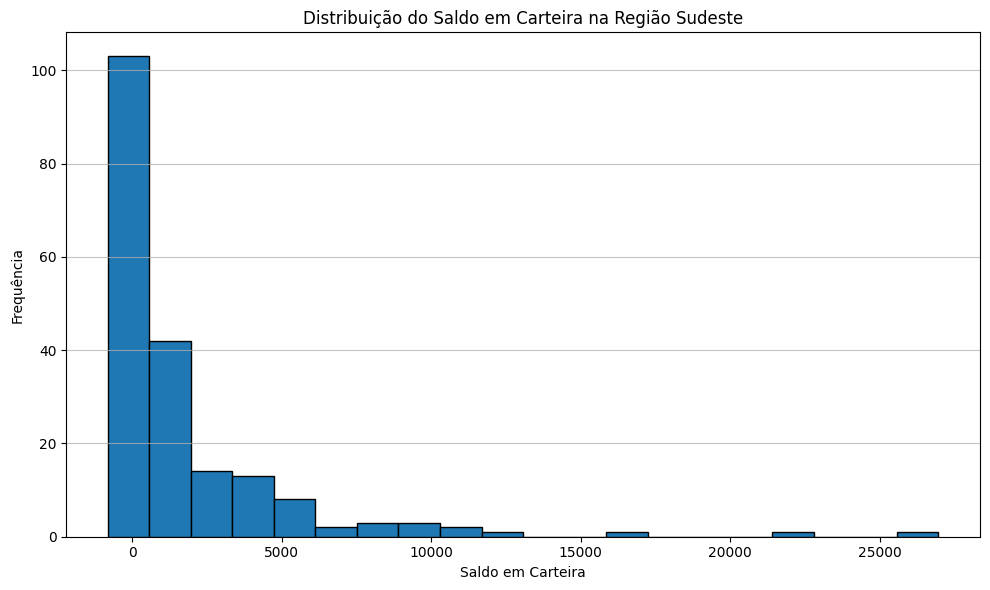


Análise:
Após a geração do histograma, observe:
- Qual é a faixa de saldo mais comum entre os clientes do Sudeste?
- A distribuição é simétrica ou assimétrica?
- Há muitos clientes com saldos muito altos ou muito baixos (outliers)?
- Como os saldos se distribuem ao longo das 20 barras?


In [12]:
# Filtrar os dados para a região Sudeste
sudeste_df = df_completo[df_completo['regiao'] == 'Sudeste']

# Criar o histograma
plt.figure(figsize=(10, 6))
plt.hist(sudeste_df['saldo_carteira'], bins=20, edgecolor='black')

plt.title('Distribuição do Saldo em Carteira na Região Sudeste')
plt.xlabel('Saldo em Carteira')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.savefig('histograma_saldo_sudeste.png')
plt.show()

# Análise (após visualizar o histograma)
print("\nAnálise:")
print("Após a geração do histograma, observe:")
print("- Qual é a faixa de saldo mais comum entre os clientes do Sudeste?")
print("- A distribuição é simétrica ou assimétrica?")
print("- Há muitos clientes com saldos muito altos ou muito baixos (outliers)?")
print("- Como os saldos se distribuem ao longo das 20 barras?")

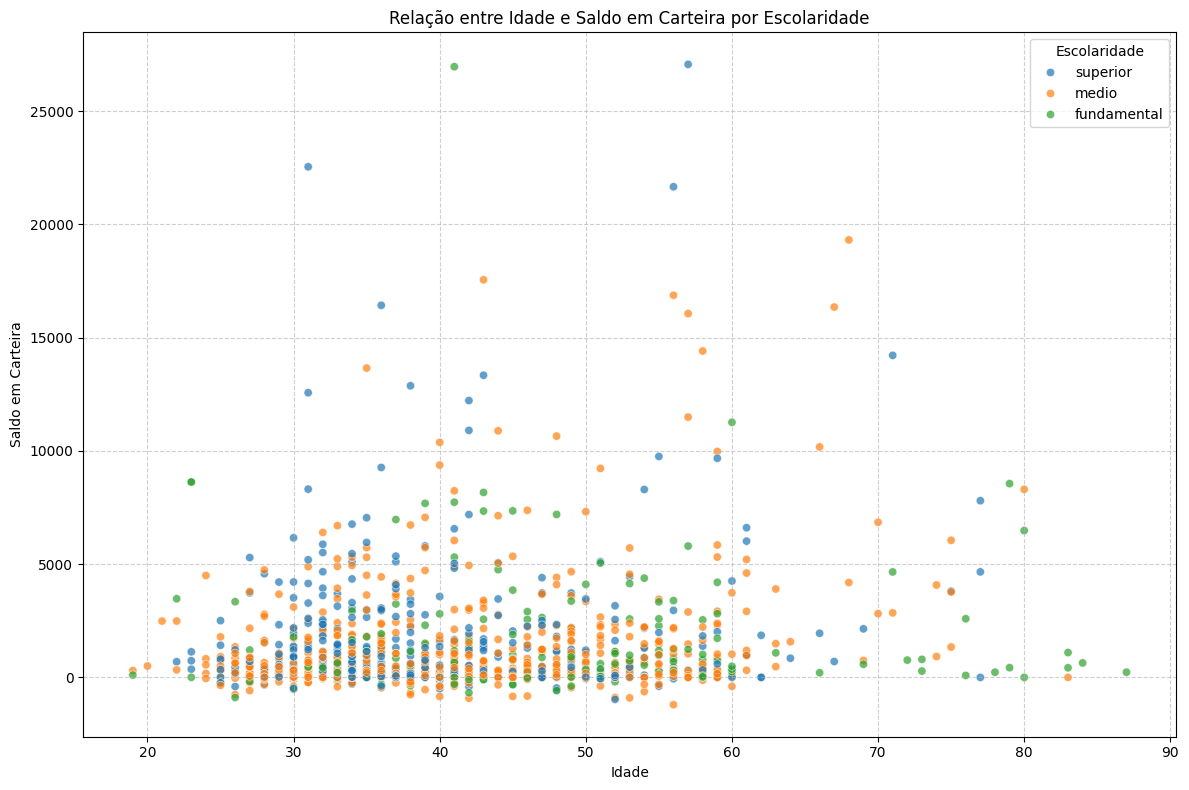


Análise:
Após a geração do gráfico, analise os padrões visíveis. Por exemplo:
- Há alguma tendência clara entre idade e saldo para alguma escolaridade?
- Os saldos tendem a aumentar com a idade?
- Há grupos de escolaridade com saldos significativamente diferentes?
- Há outliers aparentes?


In [13]:
# Criando o gráfico de dispersão
plt.figure(figsize=(12, 8))  # Tamanho ajustado para melhor visualização
sns.scatterplot(x='idade', y='saldo_carteira', hue='escolaridade', data=df_completo, alpha=0.7)

plt.title('Relação entre Idade e Saldo em Carteira por Escolaridade')
plt.xlabel('Idade')
plt.ylabel('Saldo em Carteira')
plt.legend(title='Escolaridade')
plt.grid(True, linestyle='--', alpha=0.6)  # Adicionando grade para facilitar a leitura
plt.tight_layout()
plt.savefig('idade_saldo_escolaridade_dispersao.png')
plt.show()


# Análise (isso deve ser feito após a visualização do gráfico)
print("\nAnálise:")
print("Após a geração do gráfico, analise os padrões visíveis. Por exemplo:")
print("- Há alguma tendência clara entre idade e saldo para alguma escolaridade?")
print("- Os saldos tendem a aumentar com a idade?")
print("- Há grupos de escolaridade com saldos significativamente diferentes?")
print("- Há outliers aparentes?")

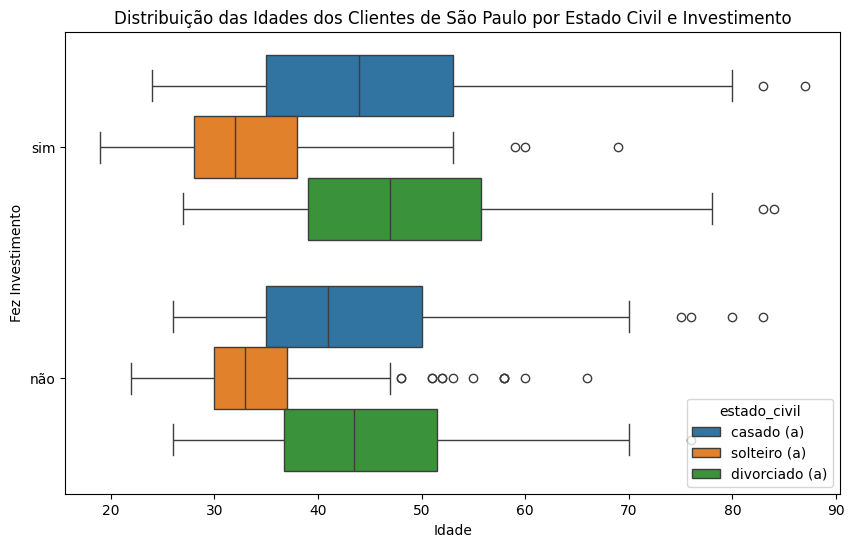


Análise:
Após a geração do gráfico, analise os padrões visíveis. Por exemplo:
- Há diferenças na distribuição das idades entre os clientes que fizeram e não fizeram investimento?
- O estado civil influencia na faixa etária dos investidores?
- Há algum estado civil com maior concentração de investidores em certas idades?
- Há outliers aparentes em relação à idade?


In [22]:
# Criar o boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='idade', y='fez_investimento', hue='estado_civil', data=df_completo, orient='h')

# Adicionar título e rótulos
plt.title('Distribuição das Idades dos Clientes de São Paulo por Estado Civil e Investimento')
plt.xlabel('Idade')
plt.ylabel('Fez Investimento')

# Mostrar o gráfico
plt.show()

# Análise (após a visualização do gráfico)
print("\nAnálise:")
print("Após a geração do gráfico, analise os padrões visíveis. Por exemplo:")
print("- Há diferenças na distribuição das idades entre os clientes que fizeram e não fizeram investimento?")
print("- O estado civil influencia na faixa etária dos investidores?")
print("- Há algum estado civil com maior concentração de investidores em certas idades?")
print("- Há outliers aparentes em relação à idade?")

In [15]:
# Calcular a soma do saldo_carteira por estado
saldo_por_estado = df_completo.groupby('estado')['saldo_carteira'].sum()

# Encontrar a cidade com a maior soma
estado_maior_saldo = saldo_por_estado.idxmax()
maior_saldo = saldo_por_estado.max()

# Imprimir o resultado
print(f"O estado com o maior saldo em carteira é {estado_maior_saldo} com um saldo total de {maior_saldo}.")


O estado com o maior saldo em carteira é Espiríto Santo com um saldo total de 114718.


In [16]:
# Preparando os dados para o modelo

# Separando features e target
X = df_completo.drop('fez_investimento', axis=1, errors='ignore') # Usando errors='ignore'
y = df_completo['fez_investimento']

# Tratando variáveis categóricas com OneHotEncoder
categorical_cols = X.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, drop='first') # sparse_output=False para compatibilidade
encoded_cats = encoder.fit_transform(X[categorical_cols])
encoded_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(categorical_cols))

# Removendo colunas categóricas originais e adicionando as codificadas
X = X.drop(categorical_cols, axis=1, errors='ignore')  # Usando errors='ignore'
X = pd.concat([X.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

# Exibindo as primeiras linhas e informações do DataFrame resultante
print("Primeiras linhas do DataFrame X após a codificação:")
print(X.head())

print("\nInformações do DataFrame X após a codificação:")
print(X.info())

Primeiras linhas do DataFrame X após a codificação:
   idade  saldo_carteira  ultimo_contato_tempo  numero_contatos  cod_estado  \
0   45.0             242                   587                1          27   
1   42.0            1289                   250                4          11   
2   23.0             363                    16               18          25   
3   58.0            1382                   700                1           6   
4   50.0            3357                   239                4          13   

   id_estado  estado_civil_divorciado (a)  estado_civil_solteiro (a)  \
0         27                          0.0                        0.0   
1         11                          0.0                        0.0   
2         25                          0.0                        1.0   
3          6                          1.0                        0.0   
4         13                          0.0                        0.0   

   escolaridade_medio  escolaridade_supe

In [17]:
# Balanceamento dos dados
# Aplicando RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# Aplicando TomekLinks
tl = TomekLinks(sampling_strategy='all')
X_resampled, y_resampled = tl.fit_resample(X_resampled, y_resampled)

# Verificando o balanceamento
print("\nDistribuição das classes após balanceamento:")
print(pd.Series(y_resampled).value_counts())


Distribuição das classes após balanceamento:
fez_investimento
não    397
sim    397
Name: count, dtype: int64


In [18]:
# Divisão em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Codificando y_train e y_test para 0 e 1
y_train = y_train.map({'não': 0, 'sim': 1})
y_test = y_test.map({'não': 0, 'sim': 1})

# Criação e treinamento do modelo Random Forest
# Usando os parâmetros solicitados
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=100
)

rf_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = rf_model.predict(X_test)

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nAcurácia do Modelo:", accuracy_score(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.75      0.76      0.76        80
           1       0.76      0.75      0.75        79

    accuracy                           0.75       159
   macro avg       0.75      0.75      0.75       159
weighted avg       0.75      0.75      0.75       159


Matriz de Confusão:
[[61 19]
 [20 59]]

Acurácia do Modelo: 0.7547169811320755


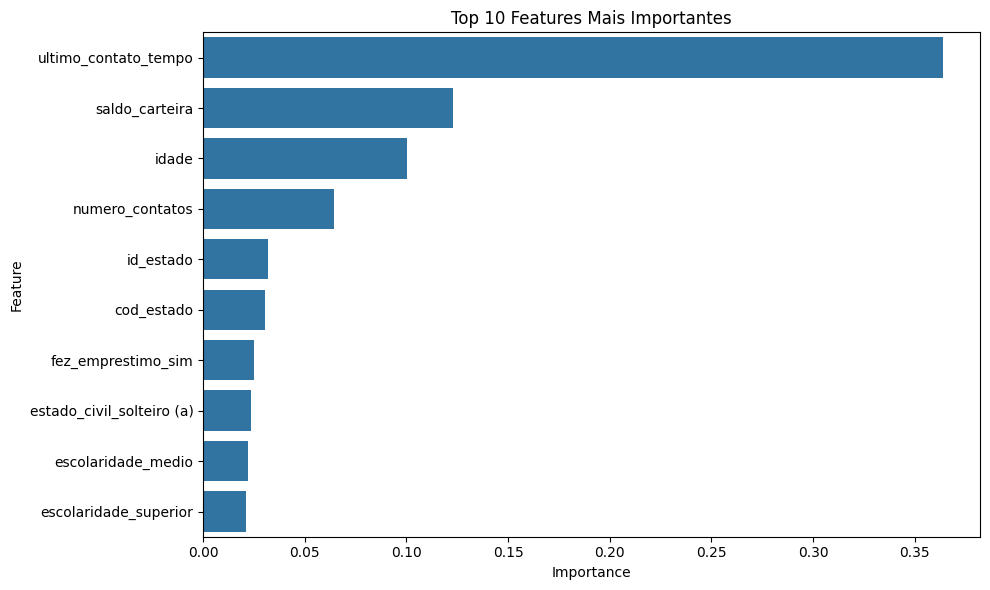

In [19]:
# Visualização da Importância das Features
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top 10 Features Mais Importantes')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

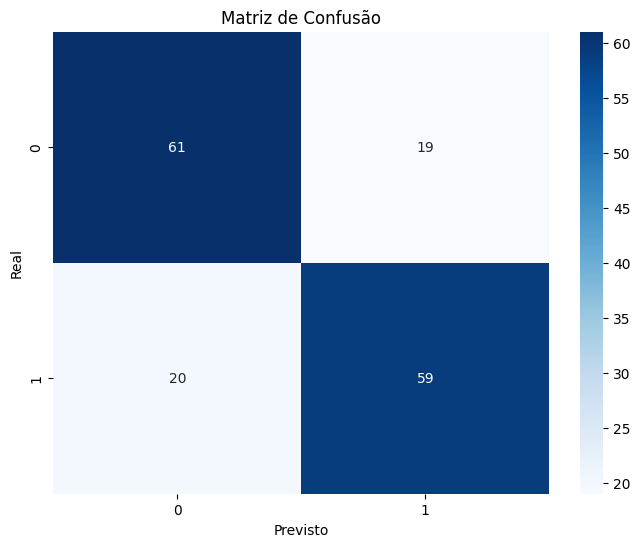

In [20]:
# Visualização da Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.savefig('confusion_matrix.png')
plt.show()

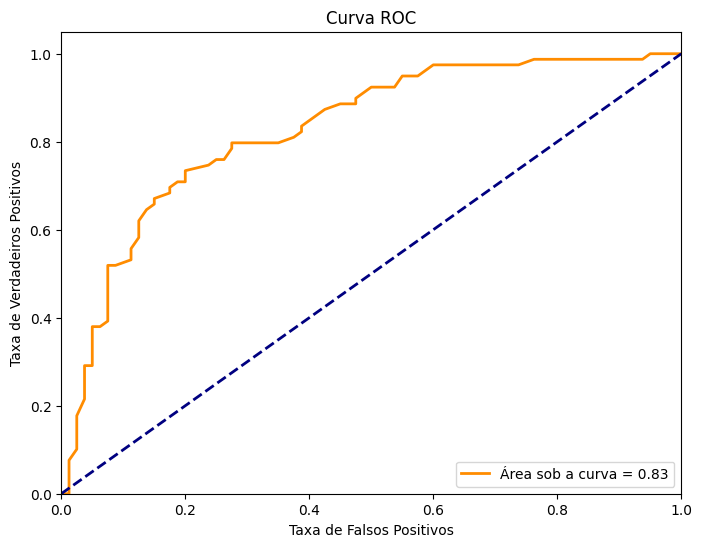

In [21]:
# Visualização da Curva ROC

y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)  # Usando pos_label=1
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Área sob a curva = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png')
plt.show()